# Exercise: End-to-End Project applied on a Vehicle Dataset

In [31]:
from pathlib import Path

import pandas as pd
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## 1. Downloading the Dataset

In [2]:
def load_vehicles_dataset():
    dataset_dir = Path('datasets/vehicle_dataset')
    if not dataset_dir.exists():
        dataset_dir.mkdir(parents=True, exist_ok=True)
        kagglehub.dataset_download(
            "nehalbirla/vehicle-dataset-from-cardekho",
            output_dir=(dataset_dir)
        )
    csv_path = dataset_dir / "CAR DETAILS FROM CAR DEKHO.csv"
    return pd.read_csv(csv_path)

In [3]:
dataset = load_vehicles_dataset()

100%|██████████| 292k/292k [00:00<00:00, 3.74MB/s]

Extracting files...


## 2. Quick Look at Data Structure

In [4]:
dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 515.2 KB


In [6]:
dataset.describe(include='all')

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
count,4340,4340.000000,4.340000e+03,4340.000000,4340,4340,4340,4340
unique,1491,NaN,NaN,NaN,5,3,2,5
top,Maruti Swift Dzire VDI,NaN,NaN,NaN,Diesel,Individual,Manual,First Owner
freq,69,NaN,NaN,NaN,2153,3244,3892,2832
mean,NaN,2013.090783,5.041273e+05,66215.777419,NaN,NaN,NaN,NaN
std,NaN,4.215344,5.785487e+05,46644.102194,NaN,NaN,NaN,NaN
min,NaN,1992.000000,2.000000e+04,1.000000,NaN,NaN,NaN,NaN
25%,NaN,2011.000000,2.087498e+05,35000.000000,NaN,NaN,NaN,NaN
50%,NaN,2014.000000,3.500000e+05,60000.000000,NaN,NaN,NaN,NaN
75%,NaN,2016.000000,6.000000e+05,90000.000000,NaN,NaN,NaN,NaN


In [32]:
dataset['name'].value_counts()

name
Maruti Swift Dzire VDI                          69
Maruti Alto 800 LXI                             59
Maruti Alto LXi                                 47
Hyundai EON Era Plus                            35
Maruti Alto LX                                  35
                                                ..
Maruti Swift LDI                                 1
Tata Nano XM                                     1
Mahindra Verito 1.5 D6 BSIII                     1
Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV     1
Hyundai i20 Magna 1.4 CRDi                       1
Name: count, Length: 1491, dtype: int64

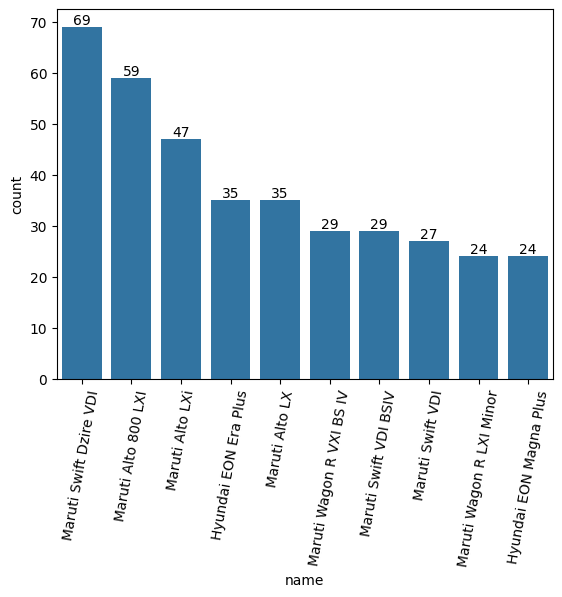

In [15]:
order = dataset['name'].value_counts().head(10).index
ax = sns.countplot(data=dataset, x='name', order=order)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=80)
plt.show()

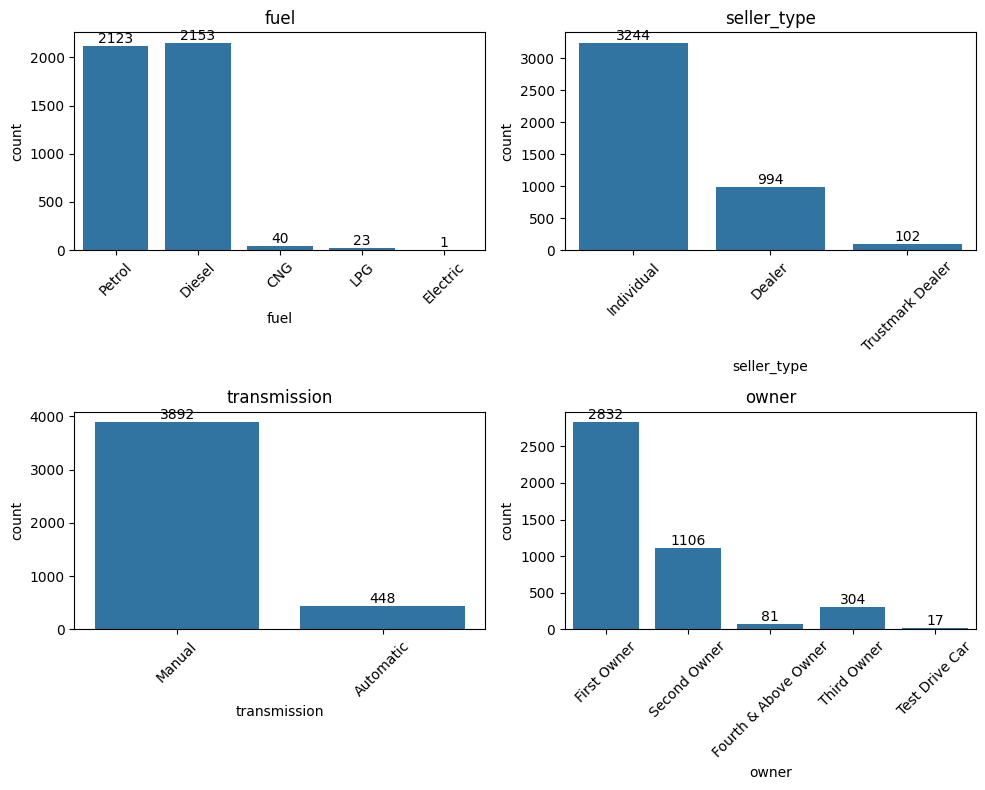

In [29]:
# We show counting graphics for all the categorical features
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

cat_columns = [
    'fuel',
    'seller_type',
    'transmission',
    'owner'
]

for ax, column in zip(axes.flatten(), cat_columns):
    sns.countplot(data=dataset, x=column, ax=ax)
    ax.set_title(column)
    ax.bar_label(ax.containers[0])
    ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

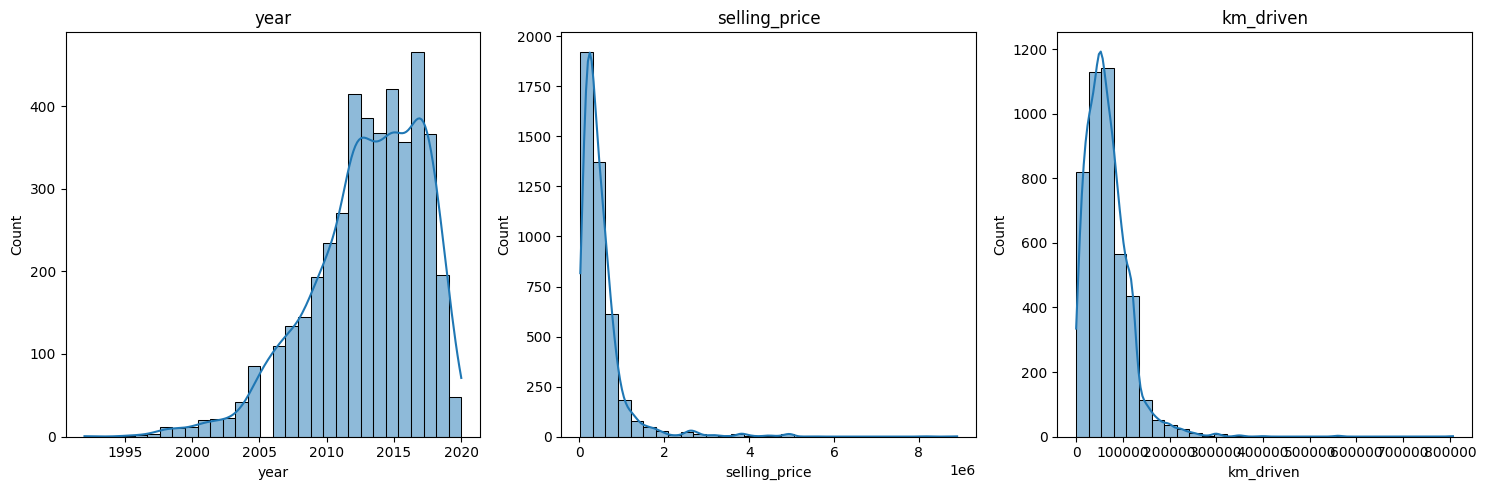

In [30]:
# We show histograms for the 3 numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
num_columns = ['year', 'selling_price', 'km_driven']

for ax, column in zip(axes.flatten(), num_columns):
    sns.histplot(data=dataset, x=column, ax=ax, bins=30, kde=True)
    ax.set_title(column)
plt.tight_layout()
plt.show()

## 3. Splitting the Dataset

In [ ]:
dataset['price_group'] = pd.cut(
    dataset['selling_price'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

In [ ]:
train_set, test_set = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    
)